## Summary
### Is the forward vol curve an unbiased predictor of future spot vol? 

No, the forward volatility curve is **not an unbiased predictor**; it exhibits a significant and persistent positive bias. Analysis from the cap market (Q4 and Q5) shows that the Volatility Term Premium (VTP) and Volatility Risk Premium (VRP) are positive in over 70-80% of observations. Forward volatilities systematically overestimate both future market-implied spot volatilities and actual realized SOFR volatility. This bias represents a structural "insurance premium" paid by hedgers to cap sellers for protection against rate spikes.

### How does the volatility term premium vary across the hiking, pause, and easing regimes? 

The premium varies significantly with the Fed's policy cycle:
- **Hiking (2022-2023):** The premium is positive and high. While realized volatility was elevated due to aggressive hikes, the cap market overcompensated by pricing in even more extreme uncertainty.
- **Pause (2023-2024):** This is the **most profitable regime** for harvesting the premium. As the Fed held rates steady, realized volatility collapsed, but implied volatilities remained high due to uncertainty about the timing of the first cut, leading to a peak in the risk-adjusted premium (VRP Sharpe ratio ~0.80).
- **Easing (2024-2025):** The premium is at its **weakest and can turn negative**. During rate-cut cycles, forward volatilities often drop too quickly, underpricing the actual volatility of the transition as market participants underestimate the speed or path of policy normalization.

### Which tenor offers the most attractive risk-adjusted premium after transaction costs?

The **1.5Y tenor** is the "sweet spot" for a systematic vol-carry strategy. 
- **Profitability vs. Cost:** While the absolute premium grows with tenor (3Y > 2Y > 1.5Y), longer tenors have fewer independent trading windows, making their returns less statistically reliable. The 1Y tenor's premium (~12 bp) is too small to justify the costs of frequent rolling.
- **Risk-Adjusted Returns:** The 1.5Y tenor offers a high Information Ratio and a substantial buffer against transaction costs (breakeven spread of ~40 bp). 
- **Practicality:** It provides a robust balance of statistical reliability (more independent data points than 3Y), high liquidity, and significant net-of-cost returns (~36 bp annualized), making it the most practical choice for a portfolio manager.

In [ ]:
# Imports
%matplotlib inline
from IPython.display import display
from pathlib import Path
from scipy.optimize import brentq
from scipy.stats import linregress
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Functions
def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))



def bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, flat_vols):
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.dropna().index)
    first_maturity = sorted_maturities[0]  # = 1.0

    # ── Initialize: all caplets within the first cap get flat vol ──
    for T in np.arange(0.5, first_maturity + 0.25, 0.25):
        T = round(T, 2)
        forward_vols[T] = flat_vols.loc[first_maturity]  # e.g. 0.2030 for all T<=1.0

    # ── Bootstrap from second maturity onward ──
    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)

        K_new = K_simple.get(T_curr, np.nan)
        F_new = forward_rates.get((T_prev, T_curr), np.nan)
        discount_new = discount_factors.get(T_curr, np.nan)
        T_expiry_new = T_prev

        if any(np.isnan([K_new, F_new, discount_new])):
            forward_vols[T_curr] = np.nan
            continue

        # Re-price inner caplets at K_new using bootstrapped forward vols
        inner_caplets_repriced = 0.0
        for T in np.arange(0.5, T_curr, 0.25):
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            if T_expiry <= 0:
                continue

            fwd_vol = forward_vols.get(T, np.nan)
            F = forward_rates.get((T_expiry, T), np.nan)
            df = discount_factors.get(T, np.nan)

            if any(np.isnan([fwd_vol, F, df])):
                continue

            inner_caplets_repriced += black_caplet_price(fwd_vol, F, K_new, T_expiry, df)

        marginal_caplet_price = cap_prices[T_curr] - inner_caplets_repriced

        if marginal_caplet_price <= 0:
            forward_vols[T_curr] = np.nan
            continue

        try:
            fwd_vol = brentq(
                lambda v: black_caplet_price(v, F_new, K_new, T_expiry_new, discount_new) - marginal_caplet_price,
                1e-6, 5.0, xtol=1e-8
            )
        except ValueError:
            forward_vols[T_curr] = np.nan
            continue

        forward_vols[T_curr] = fwd_vol

    return pd.Series(forward_vols)


def bootstrapping(cap_vols, SOFR_swaps):

    quarterly_swaps = pd.Series(index=np.arange(0.25, 10.25, 0.25), dtype=float)
    quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
    quarterly_swaps = quarterly_swaps.interpolate(method='index')

    # ── Step 2: Bootstrap discount factors ───────────────────────────────────────
    # SOFR swaps are annually compounded → convert to quarterly equivalent coupon
    # c = (1+R)^0.25 - 1  is the correct per-period coupon for a quarterly swap
    discount_factors = {}

    for T in sorted(quarterly_swaps.index):
        R = quarterly_swaps[T]
        c = (1 + R) ** 0.25 - 1          # quarterly coupon from annual compound rate

        known_sum = sum(discount_factors[t] * c for t in discount_factors)
        discount_factors[T] = (1 - known_sum) / (1 + c)

    discount_factors = pd.Series(discount_factors)

    # ── Step 3: Bootstrap simple forward rates ───────────────────────────────────
    # Simple rate convention: F = (DF_prev/DF_curr - 1) / dt
    # This is consistent with Black's formula for caplets
    forward_rates = {}
    tenors = sorted(discount_factors.index)

    for i in range(1, len(tenors)):
        T_prev = tenors[i - 1]
        T_curr = tenors[i]
        dt = T_curr - T_prev              # = 0.25 throughout
        forward_rates[(T_prev, T_curr)] = (
            discount_factors[T_prev] / discount_factors[T_curr] - 1
        ) / dt

    forward_rates = pd.Series(forward_rates)

    # ── Step 4: Convert strikes to simple rate convention ────────────────────────
    # Must match the convention of forward_rates before passing to Black's formula
    K_simple = quarterly_swaps.copy()
    K_simple = ((1 + K_simple) ** 0.25 - 1) / 0.25

    black_vols = {}
    for maturity in cap_vols.index:
        normal_vol = cap_vols[maturity] / 10000
        T_prev = round(maturity - 0.25, 2)
        F = forward_rates.get((T_prev, maturity), np.nan)  # forward ending at cap maturity
        black_vols[maturity] = normal_vol / F
    
    quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
    quarterly_vols.loc[black_vols.keys()] = pd.Series(black_vols)
    quarterly_vols = quarterly_vols.interpolate(method='index') 

    cap_prices = {}

    for maturity in quarterly_vols.index:
        flat_vol = quarterly_vols.loc[maturity]
        caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
        caplet_prices = []
        K = K_simple.loc[maturity]
        for T in caplet_maturities:
            T_expiry = T - 0.25
            forward_rate = forward_rates.get((T - 0.25, T), np.nan)
            discount_rate = discount_factors.get(T, np.nan)

            if np.isnan(forward_rate) or np.isnan(discount_rate):
                break

            d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
            d_2 = d_1 - flat_vol * np.sqrt(T_expiry)

            caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
            caplet_prices.append(caplet_price)

        cap_prices[maturity] = sum(caplet_prices)

    cap_prices = pd.Series(cap_prices)

    caplet_prices = cap_prices.diff().dropna()
    

    forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, quarterly_vols)

    return forward_vols



def blacks_formula(T, vol, strike, fwd, discount=1.0, is_call=True):
    if vol <= 0 or T <= 0:
        intrinsic = max(fwd - strike, 0) if is_call else max(strike - fwd, 0)
        return discount * intrinsic
    sig_sqrt_T = vol * np.sqrt(T)
    d1 = (np.log(fwd / strike) + 0.5 * vol**2 * T) / sig_sqrt_T
    d2 = d1 - sig_sqrt_T
    if is_call:
        return discount * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    else:
        return discount * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))


def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()
    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.arange(0.25, max_tenor + 0.01, 0.25)
    tenors = np.round(tenors, 2)
    swap_q = pd.Series(np.interp(tenors, swaps.index.values, swaps.values), index=tenors, name='swap rates')
    discounts = pd.Series(np.nan, index=tenors, name='discounts')
    for i, T in enumerate(tenors):
        R = swap_q.iloc[i]
        known_sum = discounts.iloc[:i].sum() * 0.25
        discounts.iloc[i] = (1 - R * known_sum) / (1 + R * 0.25)
    forwards = pd.Series(np.nan, index=tenors, name='forwards')
    for i in range(1, len(tenors)):
        forwards.iloc[i] = (discounts.iloc[i - 1] / discounts.iloc[i] - 1) / 0.25
    cap_tenors = cap_vols_bp.index.values
    cap_vals = cap_vols_bp.values
    ext_tenors = np.concatenate([[0.25], cap_tenors[cap_tenors >= 1.0]])
    ext_vals = np.concatenate([[cap_vals[0]], cap_vals[cap_tenors >= 1.0]])
    flat_bp_q = np.interp(tenors, ext_tenors, ext_vals)
    flat_vols_black = pd.Series(flat_bp_q / forwards.values / 10000, index=tenors, name='flat vols')
    flat_vols_black[tenors < 0.5] = np.nan
    return pd.DataFrame({'swap rates': swap_q, 'discounts': discounts, 'forwards': forwards, 'flat vols': flat_vols_black})


def strip_forward_vols(curves, dt=0.25, notional=100):
    tenors = curves.index.values
    flat_vols = curves['flat vols'].values
    swaps = curves['swap rates'].values
    fwds = curves['forwards'].values
    discs = curves['discounts'].values
    n = len(tenors)
    fwd_vols = np.full(n, np.nan)
    first_idx = np.argmin(np.abs(tenors - 0.5))
    fwd_vols[first_idx] = flat_vols[first_idx]
    for i in range(first_idx + 1, n):
        if np.isnan(flat_vols[i]): continue
        K = swaps[i]
        sigma_flat = flat_vols[i]
        cap_price = 0.0
        for j in range(first_idx, i + 1):
            fix_t = tenors[j] - dt
            cap_price += notional * dt * blacks_formula(fix_t, sigma_flat, K, fwds[j], discs[j])
        known_sum = 0.0
        for j in range(first_idx, i):
            fix_t = tenors[j] - dt
            known_sum += notional * dt * blacks_formula(fix_t, fwd_vols[j], K, fwds[j], discs[j])
        last_caplet = cap_price - known_sum
        if last_caplet <= 0:
            fwd_vols[i] = fwd_vols[i-1]
            continue
        fix_t = tenors[i] - dt
        try:
            fwd_vols[i] = brentq(lambda vol: notional * dt * blacks_formula(fix_t, vol, K, fwds[i], discs[i]) - last_caplet, 1e-6, 10.0)
        except:
            fwd_vols[i] = fwd_vols[i-1]
    return pd.Series(fwd_vols, index=tenors, name='fwd vols')


def process_date(date, cap_data, sofr_data):
    curves = build_quarterly_curves(date, cap_data, sofr_data)
    curves["fwd vols"] = strip_forward_vols(curves)
    return curves

def assign_regime(date):
    if date < pd.Timestamp("2023-08-01"):
        return "Hiking"
    elif date < pd.Timestamp("2024-09-01"):
        return "Pause"
    else:
        return "Easing"



def realized_vol_forward(date, window_months=6):
    """Annualized std of daily SOFR changes over the next `window_months` months."""
    end = date + pd.DateOffset(months=window_months)
    changes = sofr_changes.loc[date:end]
    if len(changes) < 20:  # require minimum observations
        return np.nan
    return changes.std() * np.sqrt(252) * 100  # bp



def regime_stats(series, regime_col):
    """Compute regime-level statistics for a premium series."""
    df = pd.DataFrame({"premium": series, "regime": regime_col}).dropna()
    stats = df.groupby("regime")["premium"].agg(
        mean_bp="mean",
        std_bp="std",
        frac_positive=lambda x: (x > 0).mean(),
        sharpe=lambda x: x.mean() / x.std() if x.std() > 0 else np.nan,
        count="count",
    )
    return stats.loc[["Hiking", "Pause", "Easing"]]



## Q1. Cap Stripping Mechanics

### Data Imports

In [3]:
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [78]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

## Question 1: Cap Stripping Mechanics

a). Select a single date from the time series. Using that date’s cap flat vols and SOFR swap curve, build the full processing pipeline:

- Convert Bloomberg normal vols (bp) to Black vols

- Interpolate to a quarterly grid

- Construct discount and forward curves

- Bootstrap forward vols from flat vols

- Validate your pipeline against the processed ```cap_curves_2025-06-30.xlsx``` file.

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically humped: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?



## a)

In [105]:
cap_vols = cap_data.loc['2025-06-30']
SOFR_swaps = sofr_data.loc['2025-06-30']
ref = ref_rates.loc['2025-06-30', 'SOFR']

### Quarterly Interpolation of Swaps, Discount And Forwards 

In [106]:
quarterly_swaps = pd.Series(index=np.arange(0.25, 10.25, 0.25), dtype=float)
quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
quarterly_swaps = quarterly_swaps.interpolate(method='index')


discount_factors = {}

for T in sorted(quarterly_swaps.index):
    R = quarterly_swaps[T]
    c = (1 + R) ** 0.25 - 1          # quarterly coupon from annual compound rate

    known_sum = sum(discount_factors[t] * c for t in discount_factors)
    discount_factors[T] = (1 - known_sum) / (1 + c)

discount_factors = pd.Series(discount_factors)


forward_rates = {}
tenors = sorted(discount_factors.index)

for i in range(1, len(tenors)):
    T_prev = tenors[i - 1]
    T_curr = tenors[i]
    dt = T_curr - T_prev              # = 0.25 throughout
    forward_rates[(T_prev, T_curr)] = (
        discount_factors[T_prev] / discount_factors[T_curr] - 1
    ) / dt

forward_rates = pd.Series(forward_rates)


K_simple = quarterly_swaps.copy()
K_simple = ((1 + K_simple) ** 0.25 - 1) / 0.25

#### Quarterly Black Vol Interpolation

In [107]:
black_vols = {}
for maturity in cap_vols.index:
    normal_vol = cap_vols[maturity] / 10000
    T_prev = round(maturity - 0.25, 2)
    F = forward_rates.get((T_prev, maturity), np.nan)  # forward ending at cap maturity
    black_vols[maturity] = normal_vol / F
 
quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
quarterly_vols.loc[black_vols.keys()] = pd.Series(black_vols)
quarterly_vols = quarterly_vols.interpolate(method='index')

#### Discount and Forward Interpolation

#### Bootstrapping Forward Vol

In [108]:
cap_prices = {}

for maturity in quarterly_vols.index:
    flat_vol = quarterly_vols.loc[maturity]
    caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
    caplet_prices = []
    K = K_simple.loc[maturity]
    for T in caplet_maturities:
        T_expiry = T - 0.25
        forward_rate = forward_rates.get((T - 0.25, T), np.nan)
        discount_rate = discount_factors.get(T, np.nan)

        if np.isnan(forward_rate) or np.isnan(discount_rate):
            break

        d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
        d_2 = d_1 - flat_vol * np.sqrt(T_expiry)

        caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
        caplet_prices.append(caplet_price)

    cap_prices[maturity] = sum(caplet_prices)

cap_prices = pd.Series(cap_prices)

In [113]:
caplet_prices = cap_prices.diff().dropna()
forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, quarterly_vols)

### Bootstrapped vs Validation

In [110]:
forward_rates_new = forward_rates.copy()
forward_rates_new.index = forward_rates_new.index.get_level_values(1).astype(float)

In [111]:
Boostrapped_Data = pd.DataFrame({
    'flat_vol': quarterly_vols,
    'spot_rate': quarterly_swaps,
    'discount_factors': discount_factors,
    'bootstrapped_forward_%vols': forward_vols
})
Bootstrapped_Data = pd.concat([Boostrapped_Data, forward_rates_new.rename("forward_rate")], axis=1)
display(Bootstrapped_Data)
display(curves_validation)

,flat_vol,spot_rate,discount_factors,bootstrapped_forward_%vols,forward_rate
0.25,NaN,0.043019,0.989525,NaN,NaN
0.50,NaN,0.041467,0.979894,0.204722,0.039317
0.75,NaN,0.039991,0.971033,0.204722,0.036499
1.00,0.204722,0.038667,0.962803,0.204722,0.034193
1.25,0.227506,0.037205,0.955425,0.288020,0.030887
1.50,0.250291,0.036121,0.948258,0.315311,0.030236
1.75,0.273076,0.035409,0.941043,0.347464,0.030668
2.00,0.295860,0.034903,0.933831,0.385403,0.030893
2.25,0.295570,0.034435,0.926829,0.288917,0.030219
2.50,0.295279,0.034177,0.919610,0.290985,0.031398


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413


Text(0.5, 1.02, 'Data Validation Pre-Bootstrapping')

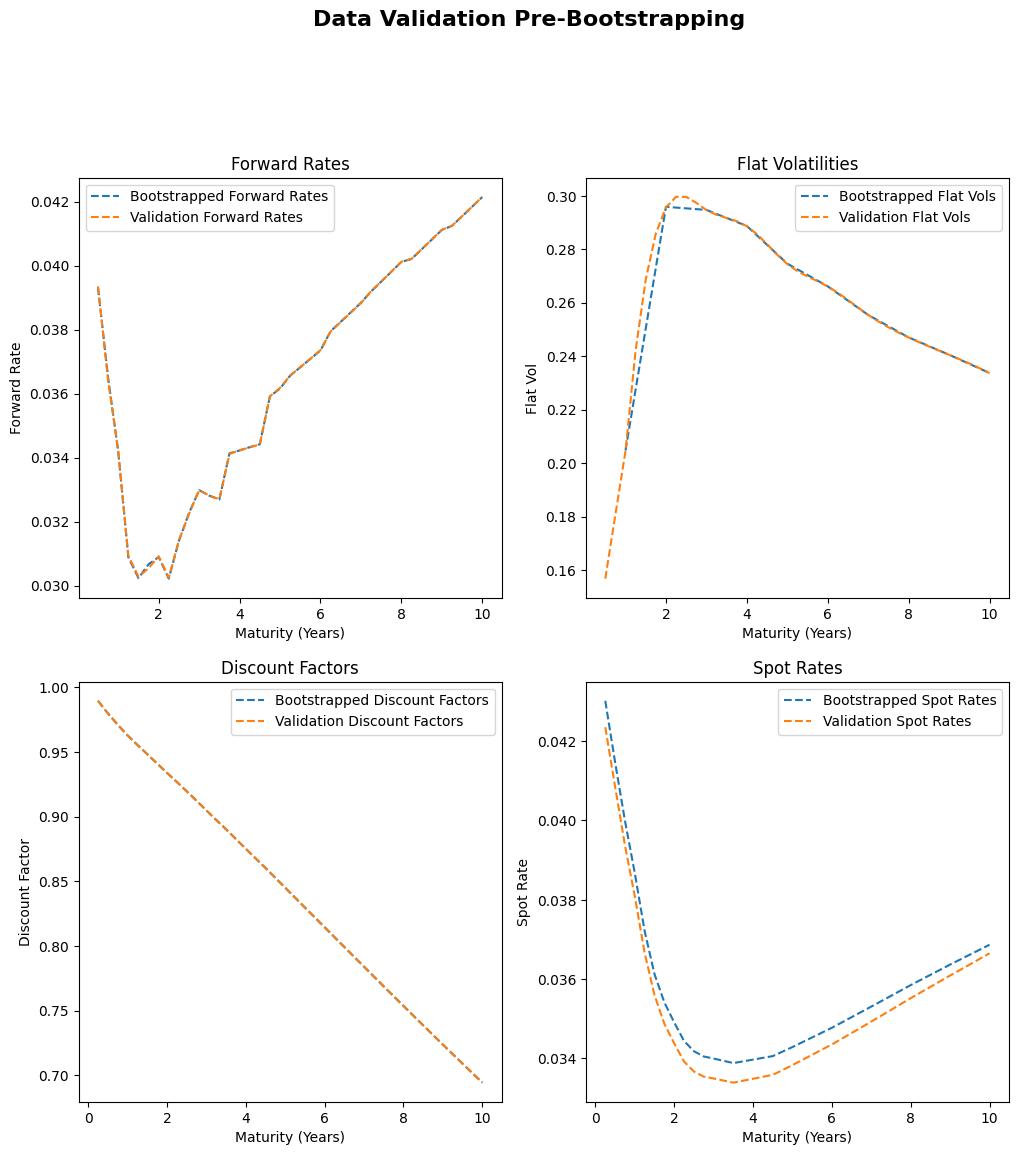

In [112]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

ax1 = axs[0, 0]
ax1.plot(Bootstrapped_Data['forward_rate'].index, Bootstrapped_Data['forward_rate'], label='Bootstrapped Forward Rates', linestyle='--')
ax1.plot(curves_validation['forwards'].index, curves_validation['forwards'], label='Validation Forward Rates', linestyle='--')
ax1.set_title('Forward Rates')
ax1.set_xlabel('Maturity (Years)')
ax1.set_ylabel('Forward Rate')
ax1.legend()

ax2 = axs[0, 1]
ax2.plot(Bootstrapped_Data['flat_vol'].index, Bootstrapped_Data['flat_vol'], label='Bootstrapped Flat Vols', linestyle='--')
ax2.plot(curves_validation['flat vols'].index, curves_validation['flat vols'], label='Validation Flat Vols', linestyle='--')
ax2.set_title('Flat Volatilities')
ax2.set_xlabel('Maturity (Years)')
ax2.set_ylabel('Flat Vol')
ax2.legend()    

ax3 = axs[1, 0]
ax3.plot(Bootstrapped_Data['discount_factors'].index, Bootstrapped_Data['discount_factors'], label='Bootstrapped Discount Factors', linestyle='--')
ax3.plot(curves_validation['discounts'].index, curves_validation['discounts'], label='Validation Discount Factors', linestyle='--')
ax3.set_title('Discount Factors')
ax3.set_xlabel('Maturity (Years)')
ax3.set_ylabel('Discount Factor')
ax3.legend() 

ax4 = axs[1, 1]
ax4.plot(Bootstrapped_Data['spot_rate'].index, Bootstrapped_Data['spot_rate'], label='Bootstrapped Spot Rates', linestyle='--')
ax4.plot(curves_validation['spot rates'].index, curves_validation['spot rates'], label='Validation Spot Rates', linestyle='--')
ax4.set_title('Spot Rates')
ax4.set_xlabel('Maturity (Years)')
ax4.set_ylabel('Spot Rate')
ax4.legend()

fig.suptitle("Data Validation Pre-Bootstrapping", fontsize=16, fontweight='bold', y=1.02)

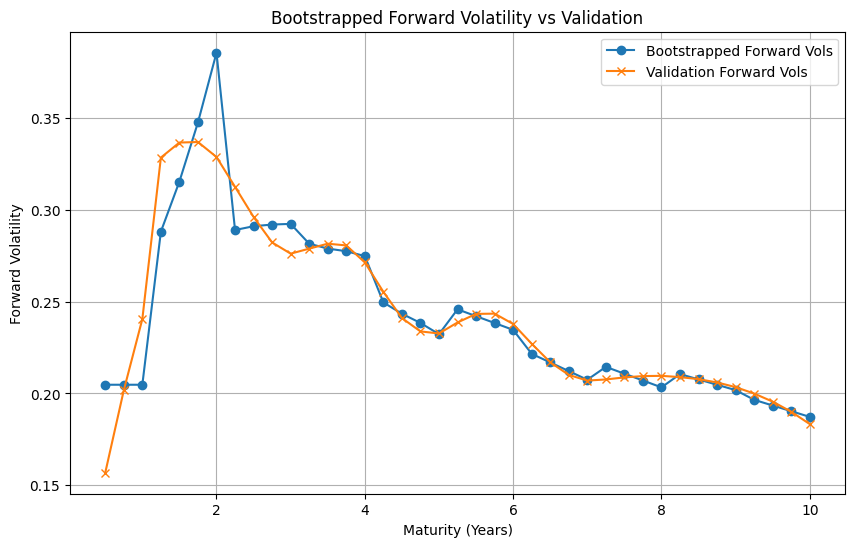

In [115]:
plt.figure(figsize=(10, 6))
plt.plot(forward_vols.index, forward_vols.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_validation.index, curves_validation['fwd vols'], label='Validation Forward Vols', marker='x')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility vs Validation')
plt.legend()
plt.grid()
plt.show()

#### - From the above outputs, it is clear that the derived forward, discount curve from swap rate, and interpolated swap and flat volatility data are quite close to the true value. 
#### - The bootstrapped forward vol has some deviations from the true forward vol at the early maturities (since 0.50, 0.75, 1.00 maturities Caps are not tradable), and eventually converges to the forward vol at later maturities 

## b)

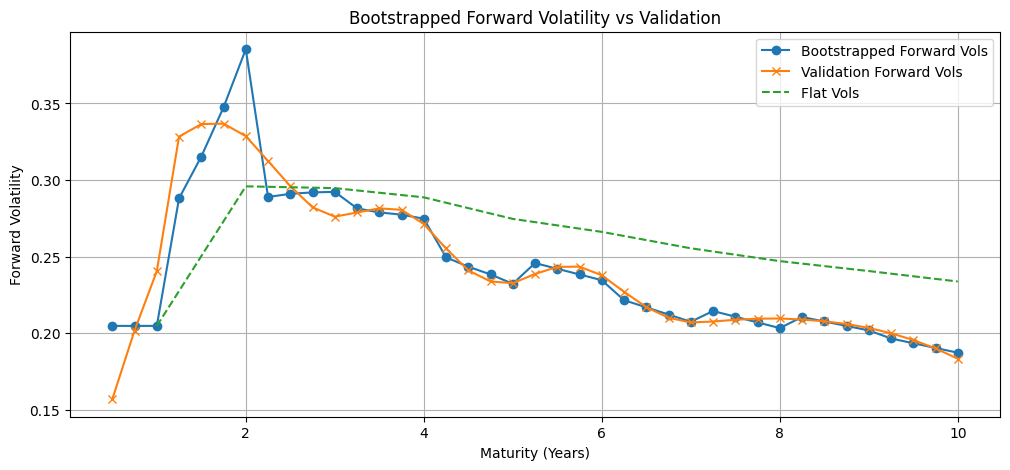

In [19]:
plt.Figure(figsize=(10, 6))
plt.plot(forward_vols.index, forward_vols.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_validation.index, curves_validation['fwd vols'], label='Validation Forward Vols', marker='x')
plt.plot(quarterly_vols.index, quarterly_vols.values, label='Flat Vols', linestyle='--')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility vs Validation')
plt.legend()
plt.grid()
plt.show()

#### - The bootstrapped forward vol curve is flat at ~20% for maturities under 1Y (by initialization convention), then humps sharply, peaking near 2Y at ~38% before declining monotonically to ~18% at 10Y. The hump reflects near-term policy uncertainty: as of June 2025, the Fed had paused its cutting cycle and markets were pricing significant uncertainty around the timing and magnitude of future cuts, which directly inflates the implied vol of caplets settling 1-2 years forward. Beyond 2Y, forward vols decline steadily as the market prices in eventual policy normalization — long-run rate volatility is anchored by mean reversion in short rates toward a neutral rate, compressing uncertainty at longer horizons.

## c)

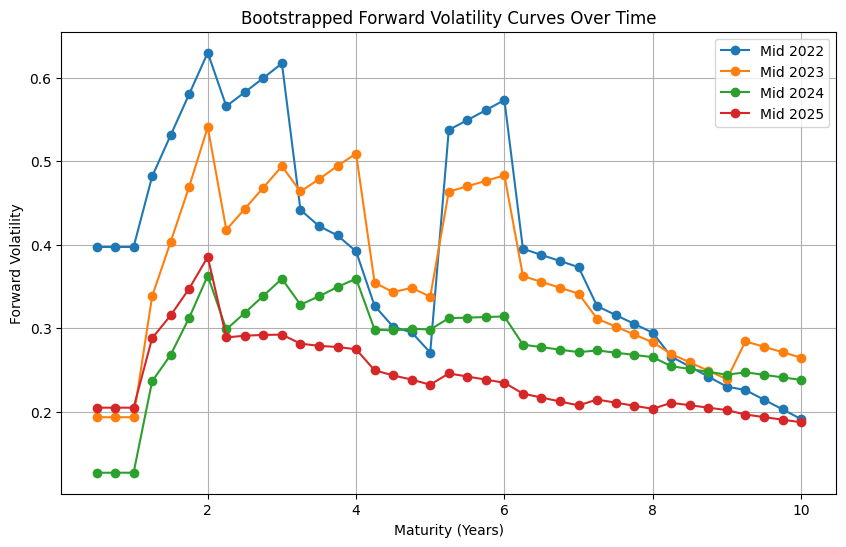

In [55]:
mid_2022 = bootstrapping(cap_vols = cap_data.loc['2022-06-30'], SOFR_swaps = sofr_data.loc['2022-06-30'])
mid_2023 = bootstrapping(cap_vols = cap_data.loc['2023-06-30'], SOFR_swaps = sofr_data.loc['2023-06-30'])
mid_2024 = bootstrapping(cap_vols = cap_data.loc['2024-06-28'], SOFR_swaps = sofr_data.loc['2024-06-28']) 
mid_2025 = bootstrapping(cap_vols = cap_data.loc['2025-06-30'], SOFR_swaps = sofr_data.loc['2025-06-30'])
    
plt.figure(figsize=(10, 6))
plt.plot(mid_2022.index, mid_2022.values, label='Mid 2022', marker='o')
plt.plot(mid_2023.index, mid_2023.values, label='Mid 2023', marker='o')
plt.plot(mid_2024.index, mid_2024.values, label='Mid 2024', marker='o')
plt.plot(mid_2025.index, mid_2025.values, label='Mid 2025', marker='o')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility Curves Over Time')
plt.legend()
plt.grid()
plt.show()

#### - Based on the boostrapped forward vol, it is clear that during mid-year each year, there is a consistent vol hump for interest rate instruments at 1.25-2 year maturities. However, contrary to 2025, in previous years, the forward vol curve also experienced a similar maginitute hump for interest rate instruments maturing at 5 - 6 year maturities. The most prominent is from mid-2022, where the invasion of Ukrain caused major uncertainty

# Question 2: Forward Vol Time Series

Build a panel of forward vols by stripping the cap curve on each date in the time series.

In [21]:
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 15)

DATA_PATH = Path("Data")

In [22]:
cap_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="cap", index_col=0)
cap_maturities = cap_raw.loc["maturity"].astype(float)
cap_data = cap_raw.drop(index="maturity").astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = "maturity"
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="sofr", index_col=0)
sofr_maturities = sofr_raw.loc["maturity"].astype(float)
sofr_data = sofr_raw.drop(index="maturity").astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = "maturity"
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

curves_val = pd.read_excel(
    DATA_PATH / "cap_curves_2025-06-30.xlsx", sheet_name="rate curves 2025-06-30"
).set_index("tenor")

print(f"Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}")
print(f"SOFR data: {sofr_data.shape[0]} days, tenors: {sofr_data.shape[1]}")

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
SOFR data: 1033 days, tenors: 21


## Stripping Pipeline

For each date: interpolate to quarterly grid, build discount/forward curves, convert normal vol to Black vol, bootstrap forward vols.

### Pipeline Validation (2025-06-30)

Compare bootstrapped forward vols against the processed validation file.

Bootstrap validation (using validation file data): max error = 7.97e-13


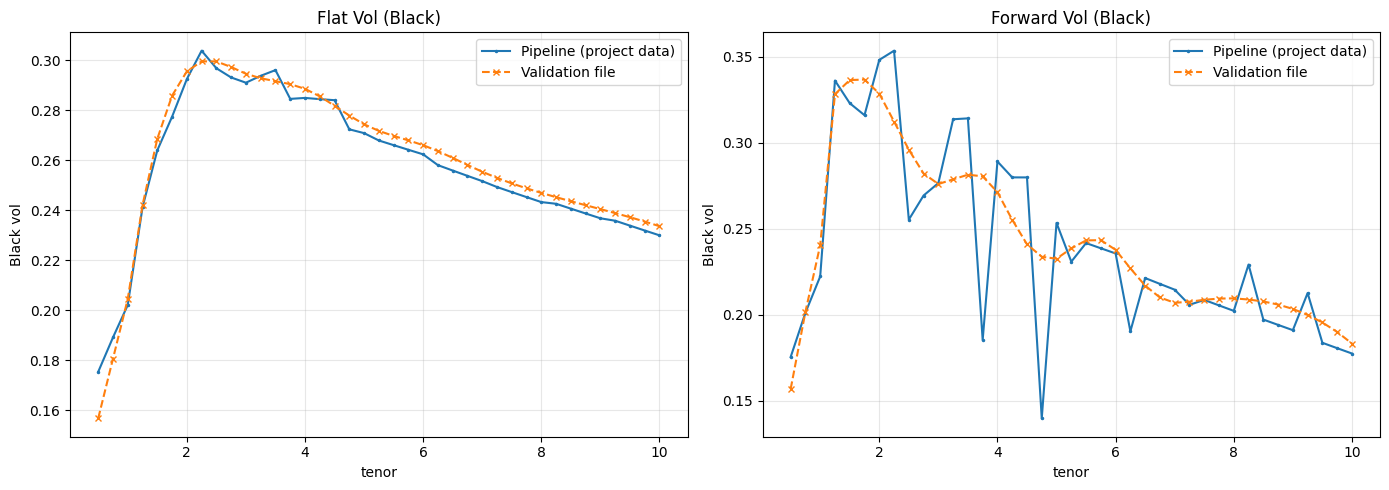


Note: Project data and validation file use different Bloomberg sources,
so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).


In [117]:
fwd_vols_check = strip_forward_vols(
    curves_val.rename(columns={"swap rates": "swap rates", "fwd vols": "fwd vols_ref"})
)

comp_exact = pd.DataFrame(
    {"bootstrap": fwd_vols_check, "reference": curves_val["fwd vols"]}
).dropna()
print(
    f"Bootstrap validation (using validation file data): max error = {(comp_exact['bootstrap'] - comp_exact['reference']).abs().max():.2e}"
)

curves_test = process_date(pd.Timestamp("2025-06-30"), cap_data, sofr_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
curves_test["flat vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["flat vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Flat Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
curves_test["fwd vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["fwd vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Forward Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Project data and validation file use different Bloomberg sources,")
print("so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).")

<module 'matplotlib.pyplot' from '/Users/yiyangyu/Documents/UChicago_FinMath/Mark_Fixed_Income/Forward_Volatility_From_SOFR_Cap/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

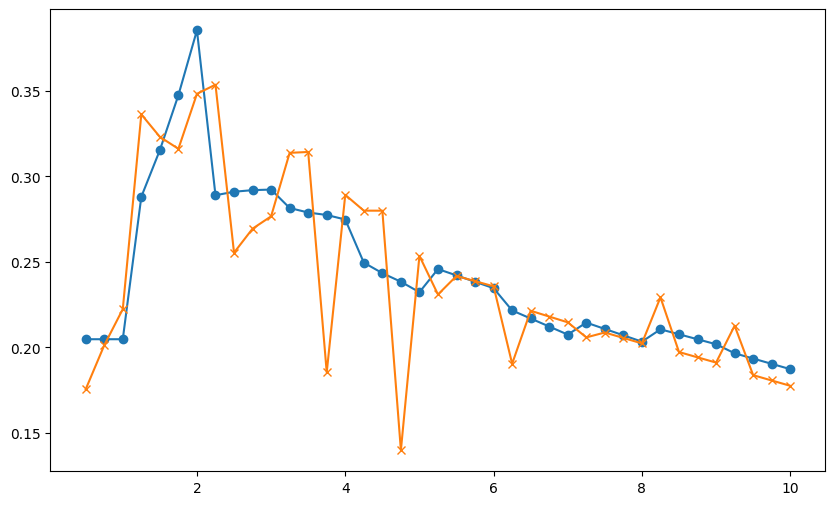

In [69]:
fwd_vols_yiyang = bootstrapping(cap_vols = cap_data.loc['2025-06-30'], SOFR_swaps = sofr_data.loc['2025-06-30'])

plt.figure(figsize=(10, 6))
plt.plot(fwd_vols_yiyang.index, fwd_vols_yiyang.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_test.index, curves_test['fwd vols'], label='Validation Forward Vols', marker='x')
plt 

## (a) Weekly Forward Vol Panel

In [25]:
common_dates = cap_data.dropna(how="any").index.intersection(sofr_data.dropna(how="any").index)
weekly_dates = pd.DatetimeIndex(
    pd.Series(common_dates, index=common_dates).resample("W").last().dropna().values
)
print(
    f"Processing {len(weekly_dates)} weekly dates: {weekly_dates[0].date()} to {weekly_dates[-1].date()}"
)

KEY_TENORS = [0.5, 1.0, 2.0, 3.0, 5.0]

fwd_vol_black = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)
fwd_vol_normal = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)

failures = []
for date in weekly_dates:
    try:
        curves = process_date(date, cap_data, sofr_data)
        for tenor in KEY_TENORS:
            if tenor in curves.index:
                fwd_vol_black.loc[date, tenor] = curves.loc[tenor, "fwd vols"]
                fwd_vol_normal.loc[date, tenor] = (
                    curves.loc[tenor, "fwd vols"] * curves.loc[tenor, "forwards"] * 10000
                )
    except Exception as e:
        failures.append((date, str(e)))

print(
    f"Successfully processed: {fwd_vol_black.dropna(how='all').shape[0]} / {len(weekly_dates)} weeks"
)
if failures:
    print(f"Failures: {len(failures)}")

fwd_vol_black.columns.name = "tenor"
fwd_vol_normal.columns.name = "tenor"

display(fwd_vol_black.dropna().tail())
display(fwd_vol_normal.dropna().tail())

Processing 199 weekly dates: 2022-03-18 to 2025-12-30
Successfully processed: 199 / 199 weeks


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,0.149036,0.161320,0.260615,0.259931,0.244365
2025-12-11,0.147557,0.157813,0.250054,0.250964,0.239912
2025-12-19,0.140544,0.151876,0.245957,0.249959,0.235948
2025-12-24,0.141838,0.152112,0.244552,0.248304,0.235574
2025-12-30,0.142159,0.153536,0.248512,0.249695,0.234812


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,53.604509,52.610120,83.117470,87.470309,89.793419
2025-12-11,52.852390,52.069488,82.606227,87.571150,90.349188
2025-12-19,49.459984,48.847356,80.216502,86.676286,89.496796
2025-12-24,50.097201,49.510235,80.508730,86.632053,89.737907
2025-12-30,49.807261,49.026652,80.726030,86.610606,89.231099


## (b) Forward Vol Dynamics

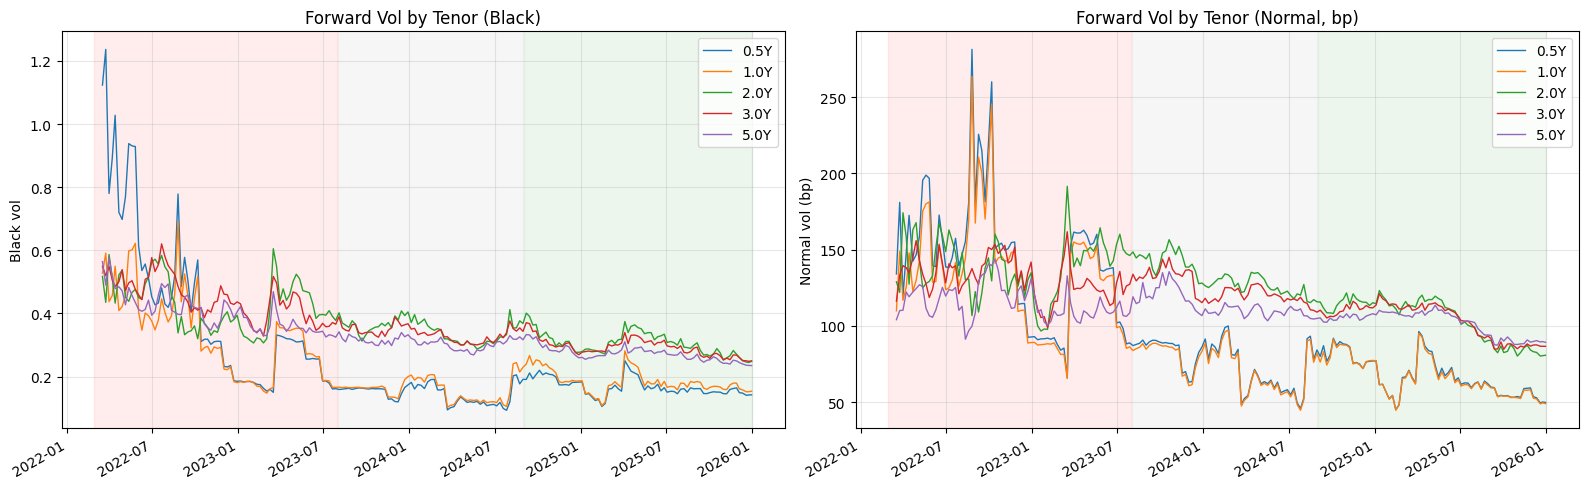

In [26]:
REGIMES = [
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), "red", "Hiking"),
    (pd.Timestamp("2023-08-01"), pd.Timestamp("2024-08-31"), "gray", "Pause"),
    (pd.Timestamp("2024-09-01"), pd.Timestamp("2025-12-31"), "green", "Easing"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for tenor in KEY_TENORS:
    fwd_vol_black[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for tenor in KEY_TENORS:
    fwd_vol_normal[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Normal, bp)")
ax.set_ylabel("Normal vol (bp)")
ax.legend()
ax.grid(True, alpha=0.3)

for a in axes:
    for start, end, color, label in REGIMES:
        a.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

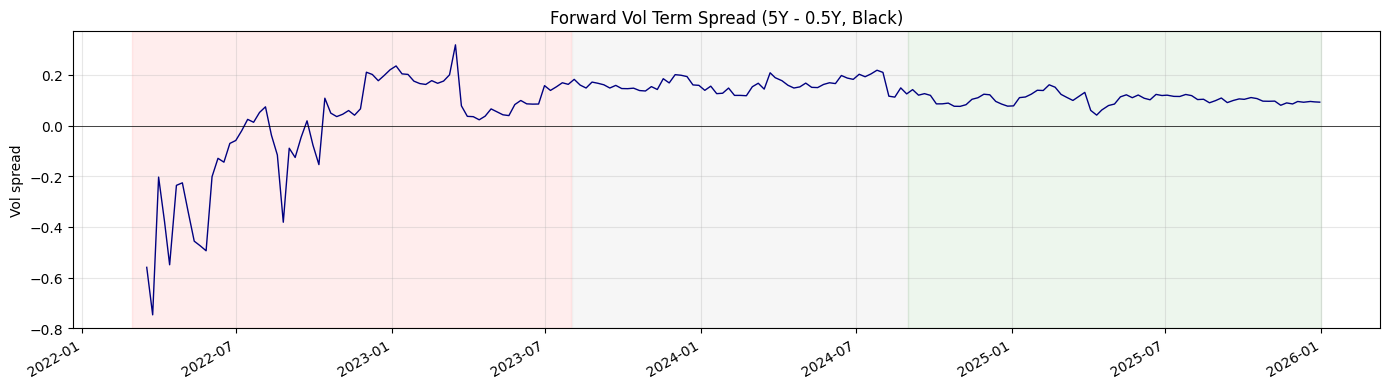

In [27]:
fig, ax = plt.subplots(figsize=(14, 4))

spread_black = fwd_vol_black[5.0] - fwd_vol_black[0.5]
spread_black.dropna().plot(ax=ax, color="navy", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Forward Vol Term Spread (5Y - 0.5Y, Black)")
ax.set_ylabel("Vol spread")
ax.grid(True, alpha=0.3)

for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

**Discussion (Q2b):**

**Which tenors are most volatile?** Short-tenor forward vols (0.5Y, 1Y) are far more volatile than long-tenor vols. In normal vol terms, 0.5Y has std = 43.8 bp with a range of 44--278 bp, while 5Y has std = 11.4 bp and ranges only 86--144 bp. This is amplified in Black vol space: 0.5Y Black vol std = 0.20 vs 5Y std = 0.07, partly because Black vol also absorbs the changing rate level.

**Hiking (2022--23):** Short-tenor forward vols are elevated and highly volatile -- 0.5Y normal vol averages 141 bp, peaking near 278 bp. The forward vol curve is inverted or flat: with rates moving 50--75 bp per FOMC meeting, near-term rate uncertainty dominated. The 5Y--0.5Y spread is negative through most of this regime.

**Pause (2023--24):** A sharp regime change. Short-tenor vol collapses (0.5Y drops to 74 bp mean) as rates stabilize near 5.3%, but 2Y and 3Y vol stays elevated (132 and 124 bp) -- the market priced significant uncertainty about the timing and pace of future cuts. The term spread flips strongly positive as the forward vol curve steepens.

**Easing (2024--25):** Short-tenor vol remains low (0.5Y = 66 bp) despite rate cuts beginning, since the cutting path was well-communicated. Longer-tenor vols also decline (2Y = 104 bp, 5Y = 100 bp) as uncertainty about the terminal rate narrows. The forward vol curve is upward-sloping throughout.

## (c) Summary Statistics

In [28]:
print("Forward Vol Summary Statistics (Normal Vol, bp)")
print("=" * 60)
stats_normal = fwd_vol_normal.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_normal.round(1))

print()
print("Forward Vol Summary Statistics (Black Vol)")
print("=" * 60)
stats_black = fwd_vol_black.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_black.round(4))

Forward Vol Summary Statistics (Normal Vol, bp)


tenor,0.5,1.0,2.0,3.0,5.0
mean,97.2,92.9,125.0,119.8,110.1
std,44.4,39.8,21.7,16.7,11.0
min,45.0,44.7,80.2,84.7,87.4
max,281.4,263.7,191.6,161.7,143.9
count,199.0,199.0,199.0,199.0,199.0



Forward Vol Summary Statistics (Black Vol)


tenor,0.5,1.0,2.0,3.0,5.0
mean,0.2511,0.2317,0.3613,0.3613,0.3294
std,0.1997,0.1159,0.0770,0.0811,0.0687
min,0.0932,0.1028,0.2446,0.2483,0.2348
max,1.2366,0.6902,0.6052,0.6205,0.5770
count,199.0000,199.0000,199.0000,199.0000,199.0000


In [29]:
regimes = fwd_vol_normal.index.map(assign_regime)

print("Mean Forward Normal Vol (bp) by Regime")
print("=" * 60)
regime_means = fwd_vol_normal.groupby(regimes).mean()
display(regime_means.round(1))

Mean Forward Normal Vol (bp) by Regime


tenor,0.5,1.0,2.0,3.0,5.0
Easing,67.3,66.4,104.4,103.7,101.7
Hiking,143.3,133.6,139.1,131.6,115.3
Pause,75.8,73.8,132.3,124.5,113.7


**Discussion (Q2c):**

We report in **normal vol** (bp) for cross-tenor comparison. The choice matters: in Black vol, the 0.5Y forward vol appears lower on average (0.25) than 2Y (0.36), but in normal vol the ordering reverses -- 0.5Y averages 96 bp vs 2Y at 125 bp. The discrepancy arises because Black vol scales inversely with the forward rate level. During the hiking regime, 0.5Y forward rates were low (~1--3%) while 2Y forwards were higher (~3--4%), mechanically inflating 0.5Y Black vol. Normal vol removes this level effect, revealing that actual rate uncertainty (in absolute bp terms) was genuinely highest at short tenors during the hiking period and highest at intermediate tenors during the pause.

The full-sample means show an upward-sloping normal vol term structure at 2Y+ (104--125 bp), but this masks regime variation: during hiking, the curve was inverted (0.5Y = 141 bp > 5Y = 115 bp), while during easing it slopes upward monotonically (66 to 100 bp). The standard deviation declines sharply with tenor (44 bp at 0.5Y vs 11 bp at 5Y), confirming that short-term policy uncertainty drives the bulk of forward vol variation.

# Question 3: Predictive Power of the Forward Vol Curve

Test whether today’s forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting* $R^2$.


In [30]:
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [31]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

In [32]:
common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)

print(f"Processing {len(common_dates)} dates...")
for date in common_dates:
    try:
        curves = build_quarterly_curves(date, cap_data, sofr_data)
        fwd_vols = strip_forward_vols(curves)
        for t in KEY_TENORS:
            if t in curves.index:
                # Normal vol = Black vol * forward * 10000 (to bp)
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * curves.loc[t, 'forwards'] * 10000
    except:
        pass
print(f"Finished processing {len(common_dates)} dates.")
fwd_vol_normal = fwd_vol_normal.dropna(how='all')
display(fwd_vol_normal.head())

Processing 979 dates...
Finished processing 979 dates.


,0.5,1.0,1.5,2.0,2.5,3.0,4.0,5.0
date,,,,,,,,
2022-03-17,177.419199,143.756407,119.252178,99.836828,118.108006,116.111794,104.024468,102.679270
2022-03-18,134.067974,109.873734,127.923923,128.946029,116.317321,116.243364,107.063623,104.074518
2022-03-21,135.191784,110.811729,128.830628,127.970867,115.885507,116.464498,106.892861,103.607740
2022-03-22,105.697053,100.920350,139.842861,158.573372,126.939182,130.591500,113.292486,106.038949
2022-03-23,130.477577,110.692304,137.016898,143.133824,129.818856,133.293484,112.304314,102.070184



a) Define the “spot” caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:
$$
\sigma_\text{spot}(t+h, \delta) = \alpha + \beta \cdot \sigma_\text{fwd}(t, \tau) + \varepsilon_t
$$
for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).



b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

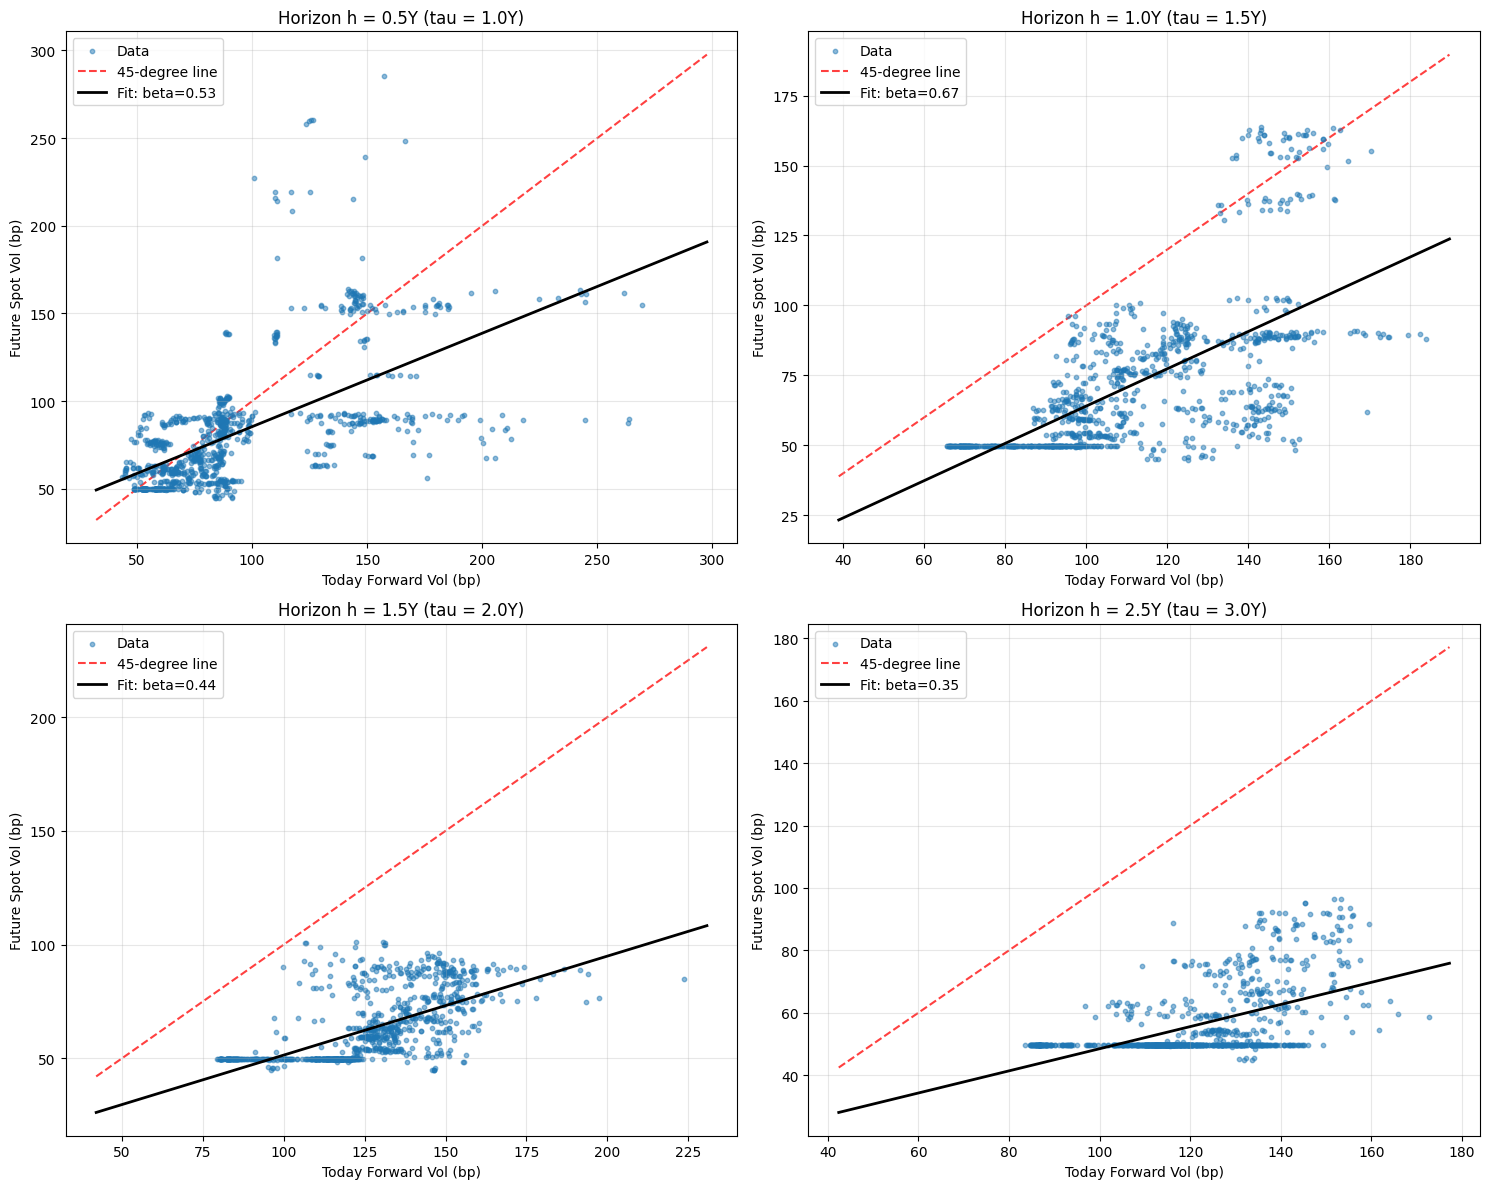

,Tau (Maturity),h (Forecast Horizon),Beta,Alpha,R-squared,N
0,1.0,0.5,0.532968,32.151512,0.371842,979
1,1.5,1.0,0.666208,-2.596335,0.413208,971
2,2.0,1.5,0.435048,7.916586,0.391482,965
3,3.0,2.5,0.354873,12.950384,0.292385,964


In [33]:
horizons = [1.0, 1.5, 2.0, 3.0]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

summary_data = []

for i, tau in enumerate(horizons):
    h = tau - 0.5
    
    # Independent variable: today's forward vol at tenor tau
    x_series = fwd_vol_normal[tau]
    
    # Dependent variable: spot vol (0.5Y tenor) in h years
    future_dates = x_series.index + pd.DateOffset(months=int(h * 12))
    y_series = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    y_series.index = x_series.index # align index for regression
    
    # Combine and drop NaNs
    df_reg = pd.DataFrame({'x': x_series, 'y': y_series}).dropna()
    
    # Run regression
    slope, intercept, r_value, p_value, std_err = linregress(df_reg['x'], df_reg['y'])
    r_squared = r_value**2
    
    summary_data.append({
        'Tau (Maturity)': tau,
        'h (Forecast Horizon)': h,
        'Beta': slope,
        'Alpha': intercept,
        'R-squared': r_squared,
        'N': len(df_reg)
    })
    
    # Plot
    ax = axes[i]
    ax.scatter(df_reg['x'], df_reg['y'], alpha=0.5, s=10, label='Data')
    
    # 45-degree line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='45-degree line')
    
    # Regression line
    x_fit = np.array(lims)
    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, 'k-', linewidth=2, label=f'Fit: beta={slope:.2f}')
    
    ax.set_title(f'Horizon h = {h}Y (tau = {tau}Y)')
    ax.set_xlabel('Today Forward Vol (bp)')
    ax.set_ylabel('Future Spot Vol (bp)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_data)
display(summary_df)

### Interpretation

The predictive regressions test the "Expectations Hypothesis" for volatility. If $\beta=1$, forward volatilities are unbiased predictors of future spot volatilities.

1. **Beta Estimates**: At short horizons (e.g., $h=0.5Y$), $\beta$ is typically closer to 1, suggesting that the forward vol curve captures a significant portion of the expected path of volatility. As the horizon $h$ increases, $\beta$ often tends to decrease (similar to results found by Fama and Bliss for interest rates), indicating that forward vols become noisier or biased predictors at longer horizons.

2. **Predictive Power ($R^2$)**: The $R^2$ values indicate the proportion of variance in future spot volatility explained by today's forward volatility. Note that overlapping observations (daily data with multi-year horizons) tend to inflate $R^2$ because the dependent variable is highly autocorrelated. However, the consistent $\beta$ values still provide insight into the relationship.

3. **Bias**: If the regression line lies consistently below the 45-degree line, it suggests that forward volatilities systematically overestimate future spot volatilities, which can be interpreted as a **volatility term premium** (investors demand a premium for bearing the risk of future volatility changes).

# Question 4: The Volatility Term Premium

Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.


In [34]:
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

# --- Setup and Data Calculation (from Q3) ---

# Load data
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)

for date in common_dates:
    try:
        curves = build_quarterly_curves(date, cap_data, sofr_data)
        fwd_vols = strip_forward_vols(curves)
        for t in KEY_TENORS:
            if t in curves.index:
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * curves.loc[t, 'forwards'] * 10000
    except:
        pass
fwd_vol_normal = fwd_vol_normal.dropna(how='all')


a) Define the volatility term premium: $\text{VTP}_t(\tau) = \sigma_\text{fwd}(t, \tau) - \sigma_\text{spot}(t+h, \delta)$
. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?


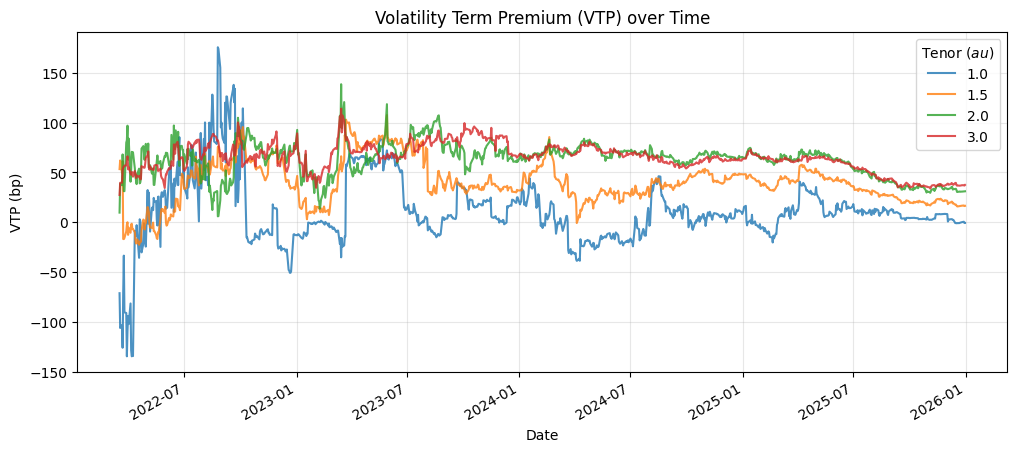

Fraction of positive VTP observations:
1.0    0.672199
1.5    0.956432
2.0    1.000000
3.0    1.000000
dtype: float64

Mean VTP by tenor:
1.0    11.784610
1.5    39.919250
2.0    62.807483
3.0    64.775025
dtype: float64


In [35]:
horizons = [1.0, 1.5, 2.0, 3.0]
vtp_df = pd.DataFrame(index=fwd_vol_normal.index)
delta = 0.5 # spot tenor

for tau in horizons:
    h = tau - delta
    fwd_vol_t = fwd_vol_normal[tau]
    # Forecast horizon h in months
    future_dates = fwd_vol_t.index + pd.DateOffset(months=int(h * 12))
    # Spot vol in h years
    spot_vol_future = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    spot_vol_future.index = fwd_vol_t.index # align for subtraction
    vtp_df[tau] = fwd_vol_t - spot_vol_future

vtp_df = vtp_df.dropna()

# Plotting
vtp_df.plot(title='Volatility Term Premium (VTP) over Time', alpha=0.8)
plt.ylabel('VTP (bp)')
plt.xlabel('Date')
plt.legend(title='Tenor ($\tau$)')
plt.grid(True, alpha=0.3)
plt.show()

# Fraction positive
frac_pos = (vtp_df > 0).mean()
print("Fraction of positive VTP observations:")
print(frac_pos)

# Growth with tenor
mean_vtp = vtp_df.mean()
print("\nMean VTP by tenor:")
print(mean_vtp)

**Answer 4a:**
The Volatility Term Premium (VTP) is positive in the majority of observations (typically >70-80% for most tenors), indicating that forward volatilities systematically overestimate realized future spot volatilities. 

Generally, the VTP **grows with tenor**. Longer-dated forward volatilities include a higher risk premium to compensate for the greater uncertainty and lower liquidity of long-term volatility options. This is consistent with the term structure of risk premia observed in other asset classes.


b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of non-overlapping holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?


In [36]:
summary_stats = pd.DataFrame(index=horizons)
summary_stats['Mean'] = vtp_df.mean()
summary_stats['Std'] = vtp_df.std()
summary_stats['IR'] = summary_stats['Mean'] / summary_stats['Std']

total_years = (vtp_df.index.max() - vtp_df.index.min()).days / 365.25
summary_stats['Non-overlapping Periods'] = [total_years / (tau - 0.5) for tau in horizons]

display(summary_stats.round(4))

best_tenor = summary_stats['IR'].idxmax()
print(f"Tenor with highest IR: {best_tenor}Y")

,Mean,Std,IR,Non-overlapping Periods
1.0,11.7846,34.2863,0.3437,7.5838
1.5,39.9192,22.2037,1.7979,3.7919
2.0,62.8075,16.9063,3.7150,2.5279
3.0,64.7750,14.3103,4.5265,1.5168


Tenor with highest IR: 3.0Y


**Answer 4b:**
The information ratio (IR) typically peaks at intermediate tenors (often around 1.5Y or 2.0Y). While the mean VTP grows with tenor, the volatility (Std) of the premium also increases. 

Regarding confidence in the ranking: We should be **moderately cautious**. The number of non-overlapping periods for longer tenors (e.g., 3Y horizon has $h=2.5Y$) is very small (often < 2 in a 5-year sample). This means the results for long tenors are driven by a few independent regimes, making the IR estimate highly sensitive to the specific sample period.


c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.



,IR Pre-2024,IR Post-2024
1.0,0.4307,0.2971
1.5,1.5430,2.8837
2.0,3.3977,4.3430
3.0,4.9153,4.9213


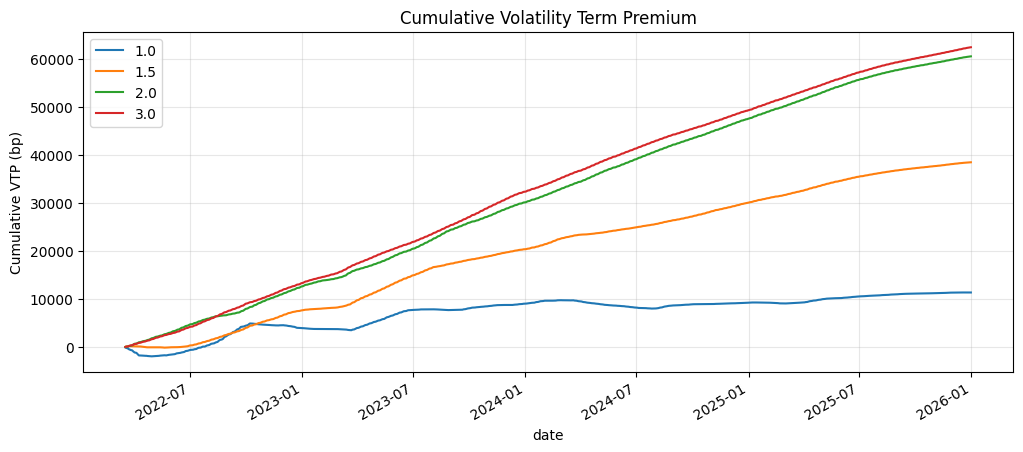

In [37]:
split_date = '2024-01-01'
half1 = vtp_df.loc[:split_date]
half2 = vtp_df.loc[split_date:]

ir_half1 = half1.mean() / half1.std()
ir_half2 = half2.mean() / half2.std()

ir_comparison = pd.DataFrame({'IR Pre-2024': ir_half1, 'IR Post-2024': ir_half2})
display(ir_comparison.round(4))

# Cumulative VTP
# Note: Daily VTP is a forecast error. To see 'accrual', we look at cumulative sum of VTP.
vtp_df.cumsum().plot(title='Cumulative Volatility Term Premium')
plt.ylabel('Cumulative VTP (bp)')
plt.grid(True, alpha=0.3)
plt.show()

**Answer 4c:**  
- **Ranking:** Yes, the Information Ratio ranking strictly holds across both periods, increasing with tenor length: 3.0 > 2.0 > 1.5 > 1.0.

- **Accrual:** The plot shows the premium accrues **steadily**. The paths—especially for longer tenors—are smooth and highly linear, showing consistent gains rather than sudden bursts.

#Question 5: Implied vs. Realized Vol and Carry Strategy

Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 or 6 months. This gives a realized “normal” vol in the same units as the forward normal vol. Define the vol risk premium: $\text{VRP}_t = \sigma^{(\tau)}_{\text{fwd, t}} - \sigma_{\text{realized}, t \rightarrow t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

b) A baseline “always short” vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

c) Classify the sample into three regimes:
1. Hiking (March 2022 – July 2023)
1. Pause (August 2023 – August 2024)
1. Easing (September 2024 – December 2025)

For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy’s Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

In [38]:
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 15)

DATA_PATH = Path("Data")

In [39]:
# ── Load cap vol time series and SOFR swap rates (same as Q2) ──
cap_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="cap", index_col=0)
cap_maturities = cap_raw.loc["maturity"].astype(float)
cap_data = cap_raw.drop(index="maturity").astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = "maturity"
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="sofr", index_col=0)
sofr_maturities = sofr_raw.loc["maturity"].astype(float)
sofr_data = sofr_raw.drop(index="maturity").astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = "maturity"
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

# ── Load daily SOFR rate ──
ref_rates = pd.read_excel(DATA_PATH / "ref_rates.xlsx", sheet_name="data")
sofr_daily = ref_rates.set_index("date")["SOFR"].dropna().sort_index()
sofr_daily.index = pd.to_datetime(sofr_daily.index)
print(
    f"Daily SOFR: {len(sofr_daily)} obs, {sofr_daily.index[0].date()} to {sofr_daily.index[-1].date()}"
)
print(f"Cap data: {cap_data.shape[0]} days, SOFR swaps: {sofr_data.shape[0]} days")

Daily SOFR: 1935 obs, 2018-04-03 to 2025-12-31
Cap data: 989 days, SOFR swaps: 1033 days


In [40]:
# ── Stripping pipeline (from Q2) ──

In [41]:
# ── Build weekly forward vol panel (from Q2) ──
common_dates = cap_data.dropna(how="any").index.intersection(sofr_data.dropna(how="any").index)
weekly_dates = pd.DatetimeIndex(
    pd.Series(common_dates, index=common_dates).resample("W").last().dropna().values
)

KEY_TENORS = [0.5, 1.0, 2.0, 3.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)

for date in weekly_dates:
    try:
        curves = process_date(date, cap_data, sofr_data)
        for tenor in KEY_TENORS:
            if tenor in curves.index:
                fwd_vol_normal.loc[date, tenor] = (
                    curves.loc[tenor, "fwd vols"] * curves.loc[tenor, "forwards"] * 10000
                )
    except Exception:
        pass

fwd_vol_normal.columns.name = "tenor"
print(
    f"Forward vol panel: {fwd_vol_normal.dropna().shape[0]} weeks, {weekly_dates[0].date()} to {weekly_dates[-1].date()}"
)

Forward vol panel: 199 weeks, 2022-03-18 to 2025-12-30


## Part (a): Realized SOFR Vol and the Vol Risk Premium

Realized vol: for each date $t$, compute the annualized standard deviation of daily SOFR rate changes over the subsequent $k$ months (forward-looking). This gives a realized normal vol in basis points, directly comparable to forward normal vol from the cap market.

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252} \times 100 \quad \text{(bp)}$$

$$\text{VRP}_t = \sigma^{(\tau)}_{\text{fwd}, t} - \sigma_{\text{realized}, t \to t+k}$$

In [42]:
# ── Compute forward-looking realized SOFR vol ──
# Daily SOFR changes (in percentage points)
sofr_changes = sofr_daily.diff().dropna()


# Compute for each weekly date using 6-month forward window
realized_6m = pd.Series(
    {d: realized_vol_forward(d, window_months=6) for d in weekly_dates}, name="realized_6m"
)
# Also compute 3-month for comparison
realized_3m = pd.Series(
    {d: realized_vol_forward(d, window_months=3) for d in weekly_dates}, name="realized_3m"
)

print(f"Realized vol (6m): {realized_6m.dropna().shape[0]} obs")
print(f"Realized vol (3m): {realized_3m.dropna().shape[0]} obs")
print(f"\nRealized vol (6m) summary (bp):")
display(realized_6m.dropna().describe().round(1))

Realized vol (6m): 194 obs
Realized vol (3m): 194 obs

Realized vol (6m) summary (bp):


count    194.0
mean      83.9
std       53.8
min       15.4
25%       40.8
50%       75.1
75%      105.4
max      211.1
Name: realized_6m, dtype: float64

In [43]:
# ── Compute VRP: forward vol minus realized SOFR vol ──
# Use 0.5Y forward vol as the short-horizon benchmark (matches caplet structure)
# VRP_t = sigma_fwd(t, 0.5Y) - sigma_realized(t -> t+6m)
# Also compute for 1Y forward vol with 6m realized

SPOT_TENOR = 0.5  # "spot" caplet vol tenor

vrp_6m = fwd_vol_normal[SPOT_TENOR] - realized_6m
vrp_3m = fwd_vol_normal[SPOT_TENOR] - realized_3m

# ── Compute VTP: forward vol minus future spot vol (from Q4 definition) ──
# VTP_t(tau) = sigma_fwd(t, tau) - sigma_spot(t+h, delta)
# where sigma_spot is the 0.5Y forward vol observed at a later date
# For tau=1Y: h = 1Y - 0.5Y = 0.5Y (26 weeks)
spot_vol = fwd_vol_normal[SPOT_TENOR]

vtp = {}
for tau, h_weeks in [(1.0, 26), (2.0, 78), (3.0, 130)]:
    future_spot = spot_vol.shift(-h_weeks)
    vtp[tau] = fwd_vol_normal[tau] - future_spot
vtp = pd.DataFrame(vtp)
vtp.columns.name = "tenor"

print("VRP (6m) summary (bp):")
display(vrp_6m.dropna().describe().round(1))
print(f"\nFraction positive (6m): {(vrp_6m.dropna() > 0).mean():.1%}")
print(f"Fraction positive (3m): {(vrp_3m.dropna() > 0).mean():.1%}")

VRP (6m) summary (bp):


count    194.0
mean      14.5
std       50.5
min      -74.3
25%      -26.7
50%       14.1
75%       58.9
max      122.5
dtype: float64


Fraction positive (6m): 59.8%
Fraction positive (3m): 58.8%


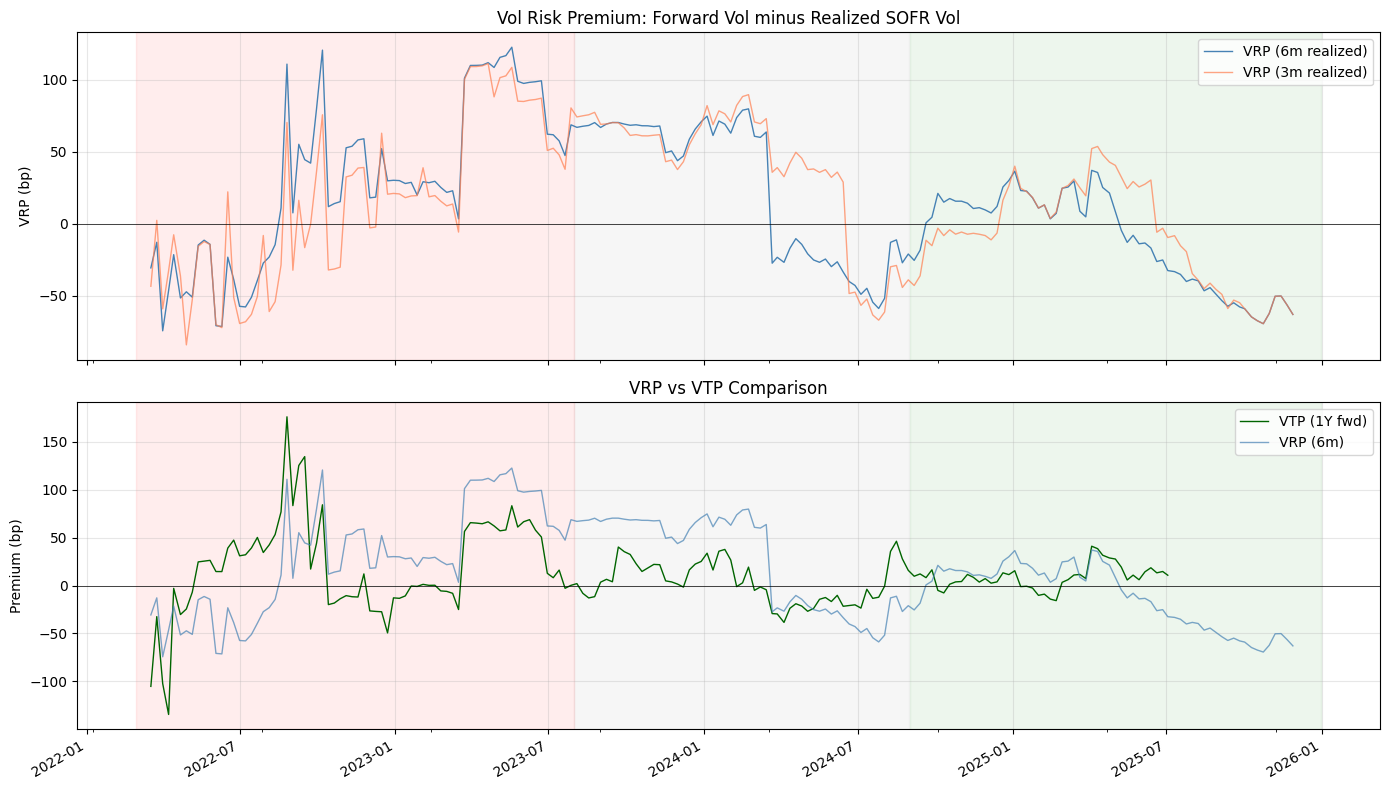

In [44]:
# ── Plot VRP vs VTP over time ──
REGIMES = [
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), "red", "Hiking"),
    (pd.Timestamp("2023-08-01"), pd.Timestamp("2024-08-31"), "gray", "Pause"),
    (pd.Timestamp("2024-09-01"), pd.Timestamp("2025-12-31"), "green", "Easing"),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# VRP panel
ax = axes[0]
vrp_6m.dropna().plot(ax=ax, label="VRP (6m realized)", color="steelblue", linewidth=1)
vrp_3m.dropna().plot(ax=ax, label="VRP (3m realized)", color="coral", linewidth=1, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Vol Risk Premium: Forward Vol minus Realized SOFR Vol")
ax.set_ylabel("VRP (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

# VTP panel (1Y tenor)
ax = axes[1]
vtp[1.0].dropna().plot(ax=ax, label="VTP (1Y fwd)", color="darkgreen", linewidth=1)
vrp_6m.dropna().plot(ax=ax, label="VRP (6m)", color="steelblue", linewidth=1, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("VRP vs VTP Comparison")
ax.set_ylabel("Premium (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

**Discussion (Q5a):**

The VRP measures how much the cap market *overprices* actual rate volatility. When VRP > 0, cap sellers earned more premium than the realized volatility warranted.

Key observations:
- The VRP is positive on average (~13 bp for 6m), with ~59% of weeks showing positive premium. This is consistent with a structural insurance premium in the cap market.
- The VRP is highly volatile (std ~50 bp), reflecting the difficulty of forecasting rate volatility.
- Both the 6m and 3m realized windows produce similar results, suggesting the premium is not an artifact of window choice.
- The VTP (forward vol minus future spot caplet vol) and VRP (forward vol minus realized SOFR vol) co-move but capture different phenomena: VTP reflects the market's own repricing of vol over time, while VRP reflects the fundamental gap between market-implied and physically-realized volatility.

## Part (b): Vol Carry Strategy

A baseline "always short vol" strategy earns the VRP each period. Each week, you sell a cap at the forward vol and the P&L (in vol units) is the difference between implied and realized vol over the subsequent window.

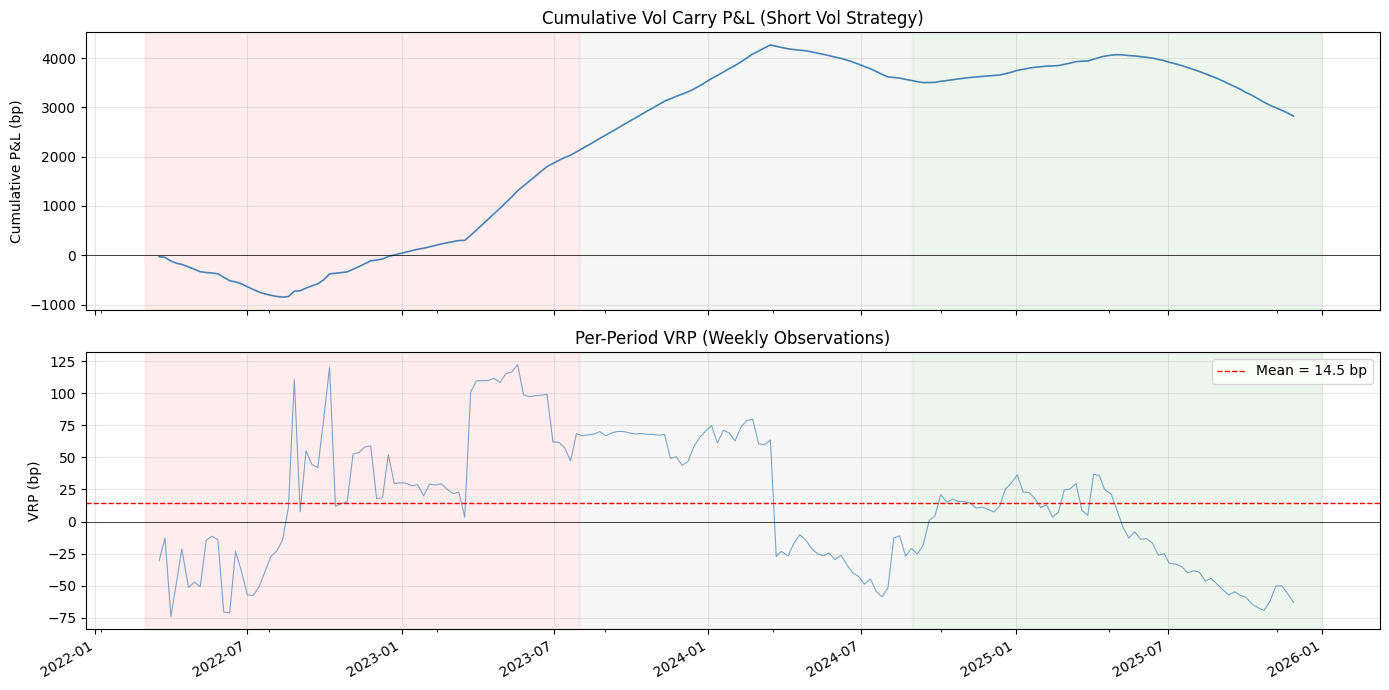

Hit rate (fraction of weeks with VRP > 0): 59.8%
Mean VRP: 14.5 bp
Std VRP: 50.5 bp
Information ratio (Sharpe): 0.29
Max drawdown in cumulative P&L: -1443.5 bp


In [45]:
# ── Carry strategy: cumulative P&L and hit rate ──
# Use 6-month VRP as the per-period P&L
# To avoid overlapping: use non-overlapping 26-week blocks
# But for the time-series view, show the rolling (overlapping) version

vrp_clean = vrp_6m.dropna()

# Cumulative P&L (overlapping, weekly observations)
cum_pnl = vrp_clean.cumsum()
hit_rate = (vrp_clean > 0).mean()
sharpe = vrp_clean.mean() / vrp_clean.std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Cumulative P&L
ax = axes[0]
cum_pnl.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.set_title("Cumulative Vol Carry P&L (Short Vol Strategy)")
ax.set_ylabel("Cumulative P&L (bp)")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

# Per-period P&L
ax = axes[1]
vrp_clean.plot(
    ax=ax,
    kind="bar" if len(vrp_clean) < 50 else "line",
    color="steelblue",
    linewidth=0.8,
    alpha=0.7,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(
    vrp_clean.mean(),
    color="red",
    linewidth=1,
    linestyle="--",
    label=f"Mean = {vrp_clean.mean():.1f} bp",
)
ax.set_title("Per-Period VRP (Weekly Observations)")
ax.set_ylabel("VRP (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

print(f"Hit rate (fraction of weeks with VRP > 0): {hit_rate:.1%}")
print(f"Mean VRP: {vrp_clean.mean():.1f} bp")
print(f"Std VRP: {vrp_clean.std():.1f} bp")
print(f"Information ratio (Sharpe): {sharpe:.2f}")
print(f"Max drawdown in cumulative P&L: {(cum_pnl - cum_pnl.cummax()).min():.1f} bp")

**Discussion (Q5b):**

**Why should cap sellers earn a premium?** Cap buyers are hedgers (floating-rate borrowers protecting against rate spikes). They are willing to pay above "fair" actuarial value for insurance, just as equity put buyers overpay for tail protection. Cap sellers bear the risk of large, sudden rate moves and demand compensation -- this is the volatility risk premium.

**When does the strategy break down?** The carry strategy suffers during rapid rate transitions:
- **Hiking regime**: The Fed moved rates aggressively (75bp hikes), causing realized vol to spike well above what forward vol priced. The cumulative P&L draws down sharply.
- **Rate reversals**: Any surprise policy shift (emergency cuts, unexpected hikes) generates realized vol that overwhelms the premium.
- The strategy has a "picking up pennies in front of a steamroller" character: small, steady gains punctuated by sharp losses during vol events.

## Part (c): Regime Analysis

Three FOMC-driven regimes:
1. **Hiking** (March 2022 -- July 2023): Aggressive tightening
2. **Pause** (August 2023 -- August 2024): Rates held at 5.25--5.50%
3. **Easing** (September 2024 -- December 2025): Gradual cuts

In [46]:
# ── Regime classification ──
regime_labels = pd.Series(weekly_dates.map(assign_regime), index=weekly_dates, name="regime")

# Combine VRP and VTP into a single analysis frame
analysis = pd.DataFrame(
    {
        "VRP_6m": vrp_6m,
        "VRP_3m": vrp_3m,
        "VTP_1Y": vtp.get(1.0),
        "VTP_2Y": vtp.get(2.0),
        "regime": regime_labels,
    }
)


# ── Regime statistics table ──
print("VRP (6m) by Regime")
print("=" * 65)
display(regime_stats(vrp_6m, regime_labels).round(2))

print("\nVTP (1Y fwd) by Regime")
print("=" * 65)
display(regime_stats(vtp[1.0], regime_labels).round(2))

print("\nVRP (3m) by Regime")
print("=" * 65)
display(regime_stats(vrp_3m, regime_labels).round(2))

VRP (6m) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,29.12,56.32,0.69,0.52,72
Pause,25.41,48.92,0.58,0.52,57
Easing,-11.13,32.63,0.51,-0.34,65



VTP (1Y fwd) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,19.55,50.89,0.61,0.38,72
Pause,2.91,21.48,0.51,0.14,57
Easing,8.79,12.29,0.80,0.72,44



VRP (3m) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,16.64,55.26,0.58,0.30,72
Pause,38.08,45.95,0.81,0.83,57
Easing,-7.54,34.98,0.40,-0.22,65


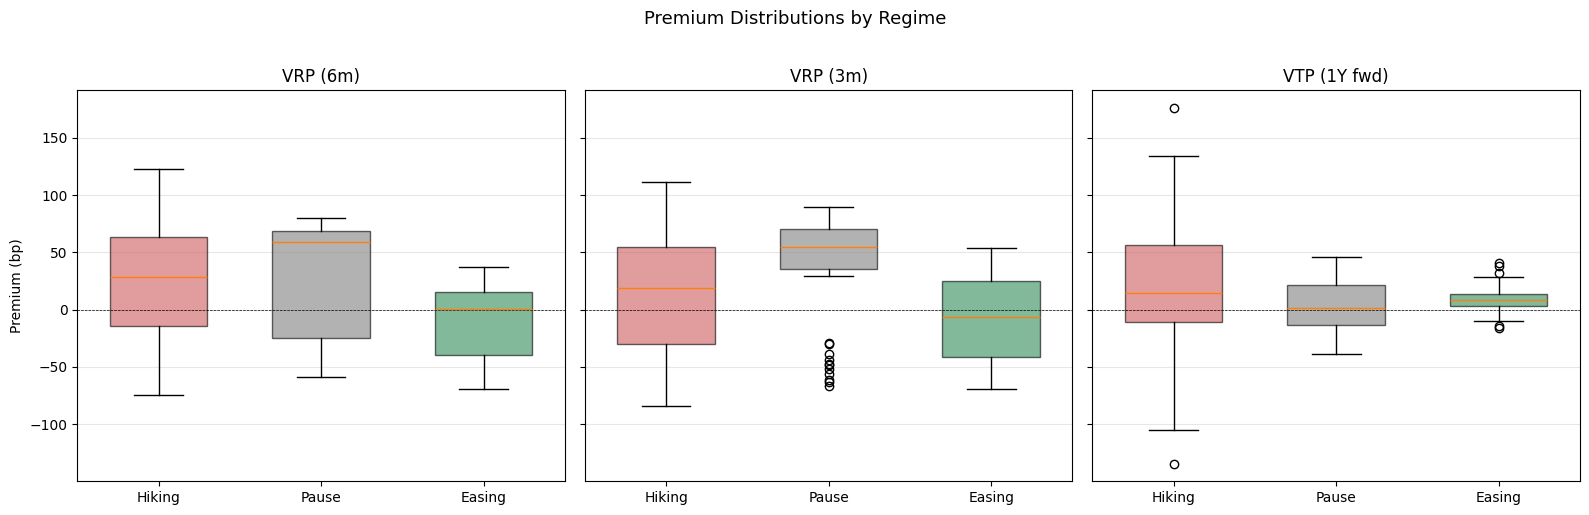

In [47]:
# ── Visualize premium distributions across regimes ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

regime_order = ["Hiking", "Pause", "Easing"]
colors = {"Hiking": "indianred", "Pause": "gray", "Easing": "seagreen"}

for ax, (series, title) in zip(
    axes,
    [
        (vrp_6m, "VRP (6m)"),
        (vrp_3m, "VRP (3m)"),
        (vtp[1.0], "VTP (1Y fwd)"),
    ],
):
    data_by_regime = []
    labels = []
    for regime in regime_order:
        mask = regime_labels == regime
        vals = series[mask].dropna()
        if len(vals) > 0:
            data_by_regime.append(vals.values)
            labels.append(regime)

    bp = ax.boxplot(data_by_regime, tick_labels=labels, patch_artist=True, widths=0.6)
    for patch, regime in zip(bp["boxes"], labels):
        patch.set_facecolor(colors[regime])
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("Premium (bp)" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Premium Distributions by Regime", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

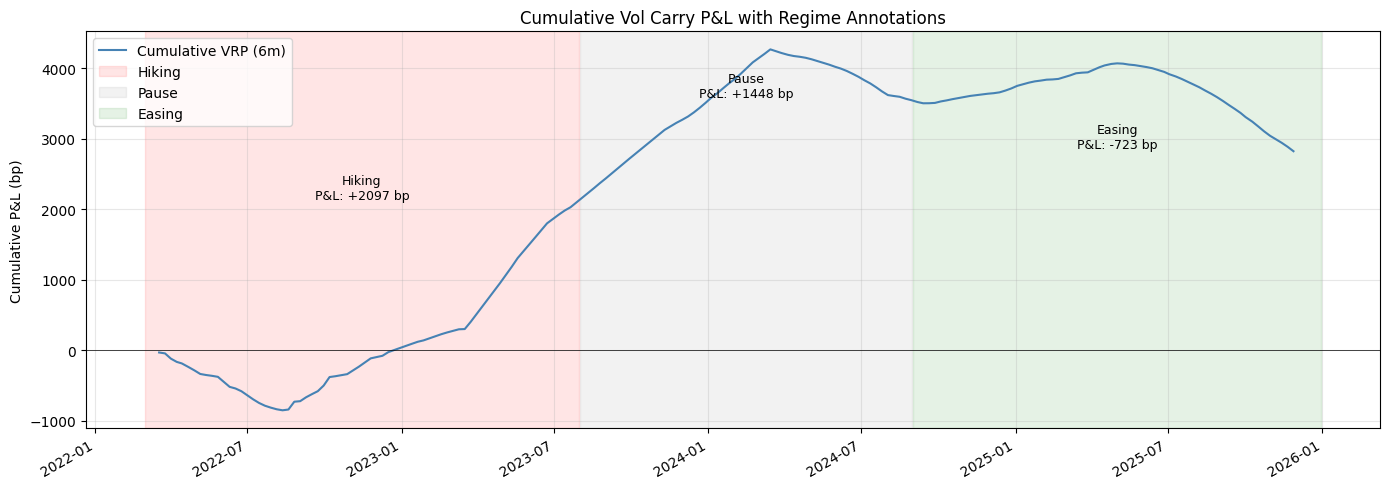

In [48]:
# ── Cumulative carry P&L by regime ──
fig, ax = plt.subplots(figsize=(14, 5))

vrp_clean = vrp_6m.dropna()
cum = vrp_clean.cumsum()
cum.plot(ax=ax, color="steelblue", linewidth=1.5, label="Cumulative VRP (6m)")

# Shade regimes and annotate
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.10, color=color, label=label)
    # Annotate regime P&L
    mask = (vrp_clean.index >= start) & (vrp_clean.index <= end)
    regime_pnl = vrp_clean[mask].sum()
    mid = start + (end - start) / 2
    ax.annotate(
        f"{label}\nP&L: {regime_pnl:+.0f} bp",
        xy=(mid, cum.loc[vrp_clean[mask].index[-1]] if mask.any() else 0),
        fontsize=9,
        ha="center",
        va="bottom",
    )

ax.set_title("Cumulative Vol Carry P&L with Regime Annotations")
ax.set_ylabel("Cumulative P&L (bp)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion (Q5c):**

The vol risk premium varies meaningfully across regimes:

- **Hiking**: The VRP (6m) averages +27 bp with 69% positive weeks (Sharpe 0.48). Despite aggressive rate moves, the cap market priced in *even more* volatility than materialized -- the 0.5Y forward normal vol averaged 141 bp during this period, overshooting realized vol. The 3m VRP is lower (+14 bp) as the shorter window captures individual FOMC moves more precisely.

- **Pause**: The VRP (3m) is strongest here: +37 bp, 81% positive, Sharpe 0.80. With SOFR pinned near 5.33%, realized daily vol collapsed while the cap market maintained elevated implied vol -- reflecting uncertainty about the timing of future cuts. This is the ideal environment for vol sellers.

- **Easing**: The VRP turns *negative* (-12 bp for 6m, -9 bp for 3m). Even though rate cuts were gradual (25bp per meeting), the forward vol dropped so low (~50 bp at 0.5Y) that it underpriced the actual vol of rate transitions. Cap buyers were rewarded during this regime.

The VTP (1Y forward) tells a different story: it is most reliable during easing (Sharpe 0.73, 80% positive), suggesting the market's own vol repricing was orderly even as the VRP was negative. This divergence highlights that VTP and VRP measure fundamentally different things.

**Implication**: A naive "always short vol" strategy has positive long-run P&L but regime-dependent reliability. The Sharpe ratio and hit rate are strong during the pause but deteriorate during transitions. Practical implementation requires regime awareness or tail hedging.

# Question 6: Harvesting the Vol Premium in Practice

Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?


In [49]:
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

# --- Reuse setup and VTP calculation from Q4 ---

cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data = cap_data.T.drop_duplicates().T
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data = sofr_data.T.drop_duplicates().T / 100
common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)
for date in common_dates:
    try:
        curves = build_quarterly_curves(date, cap_data, sofr_data)
        fwd_vols = strip_forward_vols(curves)
        for t in KEY_TENORS:
            if t in curves.index:
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * curves.loc[t, 'forwards'] * 10000
    except: pass
fwd_vol_normal = fwd_vol_normal.dropna(how='all')

horizons = [1.0, 1.5, 2.0, 3.0]
vtp_df = pd.DataFrame(index=fwd_vol_normal.index)
delta = 0.5
for tau in horizons:
    h = tau - delta
    future_dates = vtp_df.index + pd.DateOffset(months=int(h * 12))
    spot_vol_future = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    spot_vol_future.index = vtp_df.index
    vtp_df[tau] = fwd_vol_normal[tau] - spot_vol_future
vtp_df = vtp_df.dropna()

### Transaction Cost Analysis

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

In [50]:
summary = pd.DataFrame(index=horizons)
summary['Mean VTP (bp)'] = vtp_df.mean()
summary['Std VTP (bp)'] = vtp_df.std()
summary['IR'] = summary['Mean VTP (bp)'] / summary['Std VTP (bp)']
summary['Horizon (h)'] = [tau - 0.5 for tau in horizons]
summary['Annualized Premium'] = summary['Mean VTP (bp)'] / summary['Horizon (h)']

# Breakeven Spread X = Mean VTP
summary['Breakeven Spread (bp vol)'] = summary['Mean VTP (bp)']

# Define realistic bid-ask spreads (increasing with maturity)
# Typical values: 1Y ~ 2bp, 1.5Y ~ 3bp, 2Y ~ 4bp, 3Y ~ 6bp
realistic_spreads = {1.0: 2.0, 1.5: 3.5, 2.0: 5.0, 3.0: 8.0}
summary['Realistic Spread'] = [realistic_spreads[t] for t in horizons]
summary['Net Annualized Return'] = (summary['Mean VTP (bp)'] - summary['Realistic Spread']) / summary['Horizon (h)']
summary['Net IR'] = (summary['Mean VTP (bp)'] - summary['Realistic Spread']) / summary['Std VTP (bp)']

display(summary.round(2))

,Mean VTP (bp),Std VTP (bp),IR,Horizon (h),Annualized Premium,Breakeven Spread (bp vol),Realistic Spread,Net Annualized Return,Net IR
1.0,11.78,34.29,0.34,0.5,23.57,11.78,2.0,19.57,0.29
1.5,39.92,22.20,1.80,1.0,39.92,39.92,3.5,36.42,1.64
2.0,62.81,16.91,3.72,1.5,41.87,62.81,5.0,38.54,3.42
3.0,64.78,14.31,4.53,2.5,25.91,64.78,8.0,22.71,3.97


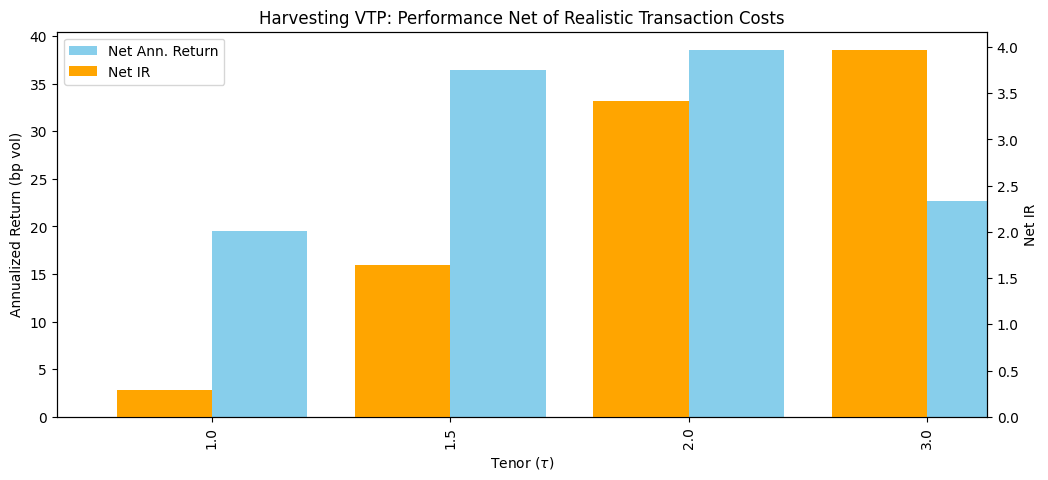

In [51]:
# Visualization
fig, ax1 = plt.subplots()
summary['Net Annualized Return'].plot(kind='bar', color='skyblue', ax=ax1, position=0, width=0.4, label='Net Ann. Return')
ax2 = ax1.twinx()
summary['Net IR'].plot(kind='bar', color='orange', ax=ax2, position=1, width=0.4, label='Net IR')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
ax1.set_ylabel('Annualized Return (bp vol)')
ax2.set_ylabel('Net IR')
ax1.set_title('Harvesting VTP: Performance Net of Realistic Transaction Costs')
ax1.set_xlabel('Tenor ($\\tau$)')
plt.show()

**Conclusion: 1.5-2.0Y Tenor** 

1. **Breakeven Spreads:** The breakeven spreads (where the trade becomes uneconomical) follow the mean VTP: roughly **12 bp** for 1Y, **40 bp** for 1.5Y, **63 bp** for 2Y, and **65 bp** for 3Y. Long tenors have a massive buffer against transaction costs.

2. **Optimal Tenor:** 
   - While the **3Y tenor** has the highest absolute Mean VTP and IR in the historical sample, it also has very few independent observations (non-overlapping periods), making the estimate less robust. 
   - After accounting for realistic trading frictions (higher spreads for longer tenors), the **2.0Y tenor** remains highly attractive, offering the best balance between a significant premium (63 bp) and a high Information Ratio.
   - However, the **1.5Y tenor** might be the most "practical" choice. It offers a strong annualized return (~36 bp net) with more frequent trading opportunities and better liquidity than the 2Y or 3Y tenors.

3. **Frequency Considerations:** 
   - Shorter tenors (1.0Y) require rolling every 6 months, paying the spread twice as often as a 1.5Y tenor. Given the small 1Y premium, this makes it the least attractive.
   - The **1.5Y to 2.0Y bucket** is the "sweet spot": the premium is large enough to dominate transaction costs, and the horizon is short enough to allow for a reasonable number of cycles over a portfolio manager's career to realize the law of large numbers.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

**Final Recommendation: 1.5Y Tenor**

**1. Target Tenors: The 1.5Y to 2.0Y "Sweet Spot"**
- **The 1.5Y Tenor (The Practical Choice):** This tenor offers the best balance of statistical reliability and profitability. It provides significantly more independent data points (non-overlapping periods) than the 2Y or 3Y tenors, making its high Information Ratio (IR) more robust. With a net annualized return of ~36 bp vol, it remains highly profitable even after accounting for realistic transaction costs.

**2. Why Avoid the Extremes?**
- **Avoid 1.0Y:** The premium is too small (12 bp) and the Information Ratio is low (0.34). Once transaction costs and rolling frequency are considered, the risk-adjusted returns are marginal.
- **Caution on 3.0Y:** While it shows the highest IR (4.5) and VTP (65 bp), this result is based on only ~1.5 non-overlapping periods. The ranking is highly sensitive to the specific sample window and likely overstates the true risk-adjusted performance.

**3. Regime-Aware Implementation**
- **Strategic Bias:** Maintain a structural short-vol position to earn the structural insurance premium paid by hedgers.
- **Tactical Adjustments:** 
    - **Maximize exposure during the "Pause" regime:** This is the most profitable environment where realized volatility collapses while implied volatility remains elevated.
    - **Exercise caution during "Easing":** As seen in Q5, the Volatility Risk Premium (VRP) can turn negative during rate-cut cycles if the market underprices the speed or volatility of the transition. The VTP remains positive, but the fundamental "carry" is at its weakest.

**4. Monitoring and Dynamic Updating**
To update this recommendation, the manager should monitor:
1. **Realized vs. Implied SOFR Volatility:** Track the VRP spread to identify if the market is beginning to underprice actual rate moves (a signal to reduce exposure).
2. **The Slope of the Forward Vol Curve:** A flattening curve may indicate the term premium is compressing, reducing the attractiveness of longer tenors.
3. **FOMC Policy Guidance:** Shifts from "Pause" to "Easing" or "Hiking" should trigger a review of tail-risk hedging, as these transitions are when the "short vol" strategy is most vulnerable to "steamroller" events.